In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
combined_df = pd.read_csv("../../data/hog_features.csv")
combined_df.columns = combined_df.columns.astype(str)


X = combined_df.drop(columns=['Cancerous', 'ID', 'Unnamed: 0'], errors='ignore')
y = combined_df['Cancerous']
image_ids = combined_df["ID"]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(X, y, image_ids, test_size=0.2, stratify=y, random_state=42)

n_estimators = 10 - train_acc: 0.975 - val_acc: 0.560
n_estimators = 50 - train_acc: 1.000 - val_acc: 0.530
n_estimators = 100 - train_acc: 1.000 - val_acc: 0.560
n_estimators = 250 - train_acc: 1.000 - val_acc: 0.660
n_estimators = 500 - train_acc: 1.000 - val_acc: 0.650
n_estimators = 750 - train_acc: 1.000 - val_acc: 0.650
n_estimators = 1000 - train_acc: 1.000 - val_acc: 0.630

max_depth_metrics = 3 - train_acc: 1.000 - val_acc: 0.570
max_depth_metrics = 4 - train_acc: 1.000 - val_acc: 0.600
max_depth_metrics = 5 - train_acc: 1.000 - val_acc: 0.720
max_depth_metrics = 6 - train_acc: 1.000 - val_acc: 0.720
max_depth_metrics = 7 - train_acc: 1.000 - val_acc: 0.650
max_depth_metrics = 8 - train_acc: 1.000 - val_acc: 0.640
max_depth_metrics = None - train_acc: 1.000 - val_acc: 0.660


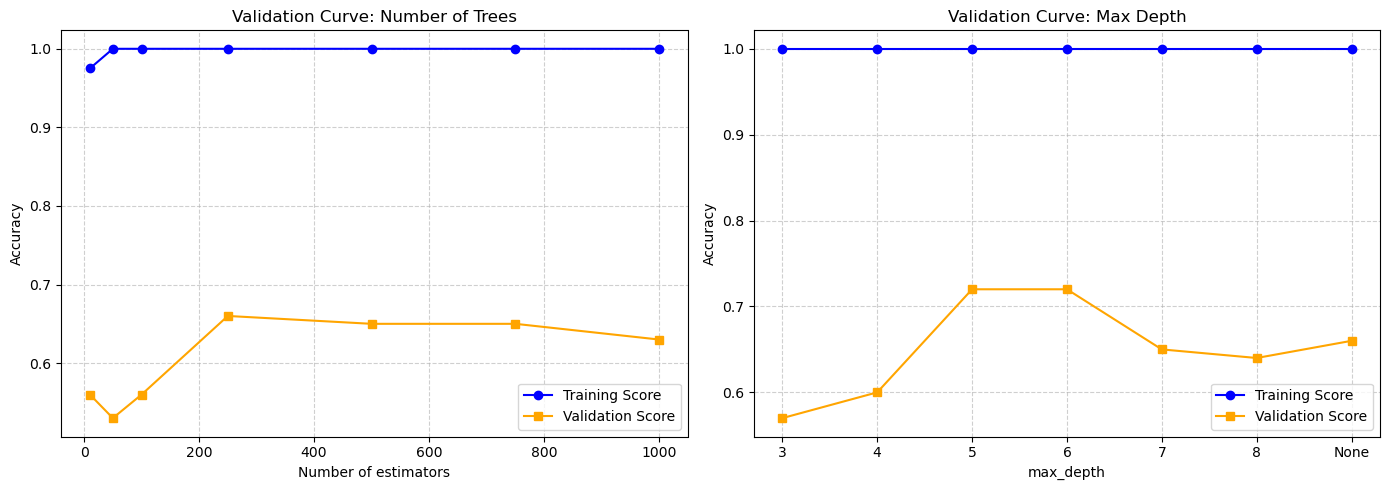

In [ ]:
n_est_metrics = {"train":[], "val":[]}
max_depth_metrics = {"train":[], "val":[]}
n_estimator = [10, 50, 100,250, 500, 750, 1000]
depth_list = [3, 4, 5, 6, 7, 8, None]

for n in n_estimator:
    rf = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42)
    rf.fit(X_train, y_train)
    train_acc = rf.score(X_train, y_train)
    val_acc = rf.score(X_test, y_test)
    n_est_metrics["train"].append(train_acc)
    n_est_metrics["val"].append(val_acc)
    print(f"n_estimators = {n} - train_acc: {train_acc:.3f} - val_acc: {val_acc:.3f}")

print("")
for d in depth_list:
    rf = RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=42, max_depth=d)
    rf.fit(X_train, y_train)
    train_acc = rf.score(X_train, y_train)
    val_acc = rf.score(X_test, y_test)
    max_depth_metrics["train"].append(train_acc)
    max_depth_metrics["val"].append(val_acc)
    print(f"max_depth_metrics = {d} - train_acc: {train_acc:.3f} - val_acc: {val_acc:.3f}")


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(n_estimator, n_est_metrics["train"], marker='o', label="Training Score", color="blue")
ax[0].plot(n_estimator, n_est_metrics["val"], marker='s', label="Validation Score", color="orange")
ax[0].set_title("Validation Curve: Number of Trees")
ax[0].set_xlabel("Number of estimators")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

depth_labels = [str(d) for d in depth_list]

ax[1].plot(depth_labels, max_depth_metrics["train"], marker='o', label="Training Score", color="blue")
ax[1].plot(depth_labels, max_depth_metrics["val"], marker='s', label="Validation Score", color="orange")
ax[1].set_title("Validation Curve: Max Depth")
ax[1].set_xlabel("max_depth")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
final_estimators = [250, 500, 750]
final_depth = [4, 5, 6, 7]

for n in final_estimators:
    for d in final_depth:
        rf_final = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42, max_depth=d)
        rf_final.fit(X_train, y_train)

        final_preds = rf_final.predict(X_test)

        plt.figure(figsize=(6,4))
        sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Blues')
        plt.title(f"Random Forest Classifier with HOG\n(0=Benign, 1=Cancer)\n Nr. of estimator: {n}, depth: {d}")
        plt.ylabel('Actual Truth')
        plt.xlabel(f'Model Prediction\nScore: {rf_final.score(X_test, y_test)}')
        plt.savefig(f"../predictions/hog/conf_matrix_{n}_estim_{d}_depth.png", dpi = 200, bbox_inches = "tight")

In [15]:
def generate_submission_csv(trained_model, test_features, test_ids, output_filename):
    """
    Takes any trained model, generates predictions and probabilities, 
    and saves them in the exact required CSV format.
    """
    labels = trained_model.predict(test_features)
    probabilities = trained_model.predict_proba(test_features)[:, 1]
    
    submission_df = pd.DataFrame({
        'image_id': test_ids,
        'label': labels,
        'probability': probabilities
    })
    
    submission_df['patient_id'] = submission_df['image_id'].apply(
        lambda x: "_".join(str(x).split("_")[:2])
    )
    
    submission_df = submission_df[['image_id', 'patient_id', 'label', 'probability']]
    
    submission_df.to_csv(output_filename, index=False)
    
    return submission_df

In [14]:
predictions_csv = generate_submission_csv(rf_final, X_test, id_test, "../predictions/hog/RF_with_HOG_predictions.csv")

predictions_csv.head()

,image_id,patient_id,label,probability
187,PAT_82_125_365.png,PAT_82,1,0.553238
230,PAT_1547_1874_432.png,PAT_1547,1,0.519501
205,PAT_1582_2574_890.png,PAT_1582,0,0.466578
292,PAT_600_1141_542.png,PAT_600,1,0.522790
381,PAT_390_790_505.png,PAT_390,0,0.498883
